# SAE Neuron Explanation Explorer

Analysis of explanation quality for sparse autoencoder neurons trained on **Qwen 2.5-3B-Instruct**, explained by DeepSeek V3.2.

**Holdout structure per neuron:** 3 high-activation + 2 low-activation examples, deterministically sampled with seed 42069.

**Scoring model:** Best-of-3. Each example gets the max score across all 3 predictions — if any prediction hits, that counts. Per-neuron score is the mean of per-example best-of-3 scores.

**Key rule:** Low-activation examples are a negative control. Quality metrics are computed on high-activation examples only — low-activation appears only in the Section 1 sanity check.

---
## Sections
1. Aggregations
2. Outliers
3. Questions

In [8]:
import json, os, glob
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 120

EXPL_DIR = 'explanations'

---
## 1. Aggregations

In [9]:
rows = []
for path in sorted(glob.glob(os.path.join(EXPL_DIR, '*_unified_scores.json'))):
    with open(path) as f:
        data = json.load(f)
    nid = data['neuron_id']
    layer = int(nid.split('_')[0])
    for res in data.get('results', []):
        if not res.get('pairs'):
            continue
        for pair in res['pairs']:
            rows.append({
                'neuron_id': nid,
                'layer': layer,
                'example_idx': res['example_idx'],
                'normalized_activation': res['normalized_activation'],
                'activation_type': res.get('activation_type', 'unknown'),
                'prediction_rank': pair['prediction_rank'],
                'concept_score': pair['concept_score'],
                'meaning_score': pair['meaning_score'],
                'overlap_fraction': pair['overlap_fraction'],
                'location_score': pair['location_score'],
                'combined_score': pair['combined_score'],
            })

df = pd.DataFrame(rows)
df_high = df[df['activation_type'] == 'high']
df_low  = df[df['activation_type'] == 'low']

print(f"Total rows: {len(df)} across {df['neuron_id'].nunique()} neurons")
print(f"  High-activation rows: {len(df_high)}")
print(f"  Low-activation rows:  {len(df_low)}")

Total rows: 12811 across 854 neurons
  High-activation rows: 7687
  Low-activation rows:  5124


In [10]:
# Best-of-3: collapse predictions per example by taking the max across all 3 ranks.
# Unit of analysis is now (neuron, example), not (neuron, example, rank).
example_scores = (
    df_high
    .groupby(['neuron_id', 'layer', 'example_idx'])
    .agg(
        best_combined         = ('combined_score',        'max'),
        best_meaning          = ('meaning_score',         'max'),
        best_overlap          = ('overlap_fraction',      'max'),
        best_concept          = ('concept_score',         'max'),
        best_location         = ('location_score',        'max'),
        normalized_activation = ('normalized_activation', 'first'),
    )
    .reset_index()
)

# Per-neuron: mean of per-example best-of-3 scores
neuron_best = (
    example_scores
    .groupby(['neuron_id', 'layer'])
    .agg(
        mean_best_combined = ('best_combined', 'mean'),
        mean_best_meaning  = ('best_meaning',  'mean'),
        mean_best_overlap  = ('best_overlap',  'mean'),
        mean_best_concept  = ('best_concept',  'mean'),
    )
    .reset_index()
)

print(f"{len(neuron_best)} neurons | {len(example_scores)} high-activation examples scored")
neuron_best.describe().round(3)

854 neurons | 2562 high-activation examples scored


,layer,mean_best_combined,mean_best_meaning,mean_best_overlap,mean_best_concept
count,854.000,854.000,854.000,854.000,854.000
mean,12.552,0.464,0.604,0.408,0.253
std,11.249,0.162,0.115,0.286,0.099
min,0.000,0.133,0.247,0.000,0.112
25%,0.000,0.344,0.519,0.212,0.184
50%,8.000,0.452,0.609,0.333,0.222
75%,17.000,0.587,0.692,0.658,0.290
max,35.000,0.863,0.895,1.000,0.868


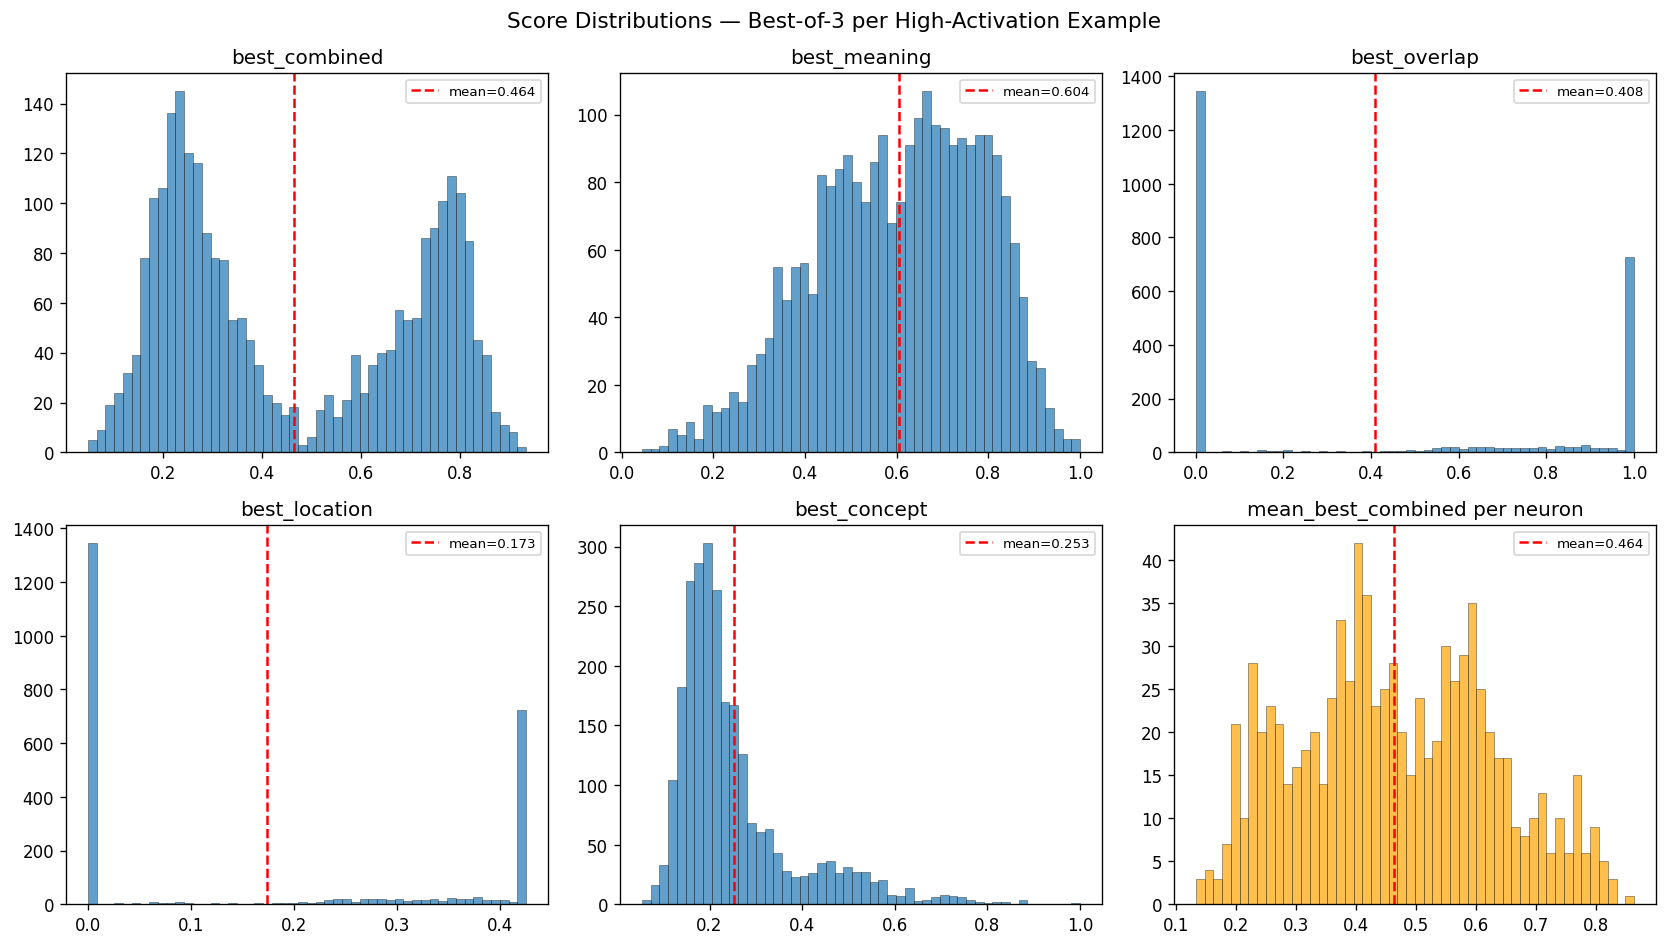

In [11]:
# Score distributions — best-of-3 per example
score_cols = ['best_combined', 'best_meaning', 'best_overlap', 'best_location', 'best_concept']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for ax, col in zip(axes.flat, score_cols):
    ax.hist(example_scores[col], bins=50, alpha=0.7, edgecolor='black', linewidth=0.3)
    ax.axvline(example_scores[col].mean(), color='red', linestyle='--',
               label=f'mean={example_scores[col].mean():.3f}')
    ax.set_title(col)
    ax.legend(fontsize=8)

ax = axes.flat[5]
ax.hist(neuron_best['mean_best_combined'], bins=50, alpha=0.7, edgecolor='black', linewidth=0.3, color='orange')
ax.axvline(neuron_best['mean_best_combined'].mean(), color='red', linestyle='--',
           label=f'mean={neuron_best["mean_best_combined"].mean():.3f}')
ax.set_title('mean_best_combined per neuron')
ax.legend(fontsize=8)

fig.suptitle('Score Distributions — Best-of-3 per High-Activation Example', fontsize=13)
plt.tight_layout()
plt.show()

,mean_best_combined_mean,mean_best_combined_median,mean_best_combined_std,mean_best_combined_count,mean_best_meaning_mean,mean_best_meaning_median,mean_best_meaning_std,mean_best_meaning_count,mean_best_overlap_mean,mean_best_overlap_median,mean_best_overlap_std,mean_best_overlap_count
layer,,,,,,,,,,,,
0,0.505,0.509,0.161,233,0.641,0.658,0.110,233,0.448,0.474,0.283,233
8,0.463,0.447,0.164,257,0.596,0.601,0.114,257,0.420,0.333,0.294,257
17,0.447,0.439,0.162,178,0.604,0.613,0.119,178,0.374,0.333,0.287,178
26,0.444,0.422,0.150,97,0.596,0.608,0.114,97,0.375,0.333,0.269,97
35,0.414,0.400,0.145,89,0.540,0.534,0.093,89,0.375,0.333,0.281,89


/var/folders/r5/jn7w490d3tb6vq90t7pnkfqh0000gn/T/ipykernel_21958/1841434814.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_layer, labels=layers, patch_artist=True)
/var/folders/r5/jn7w490d3tb6vq90t7pnkfqh0000gn/T/ipykernel_21958/1841434814.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_layer, labels=layers, patch_artist=True)
/var/folders/r5/jn7w490d3tb6vq90t7pnkfqh0000gn/T/ipykernel_21958/1841434814.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_layer, labels=layers, patch_artist=True)


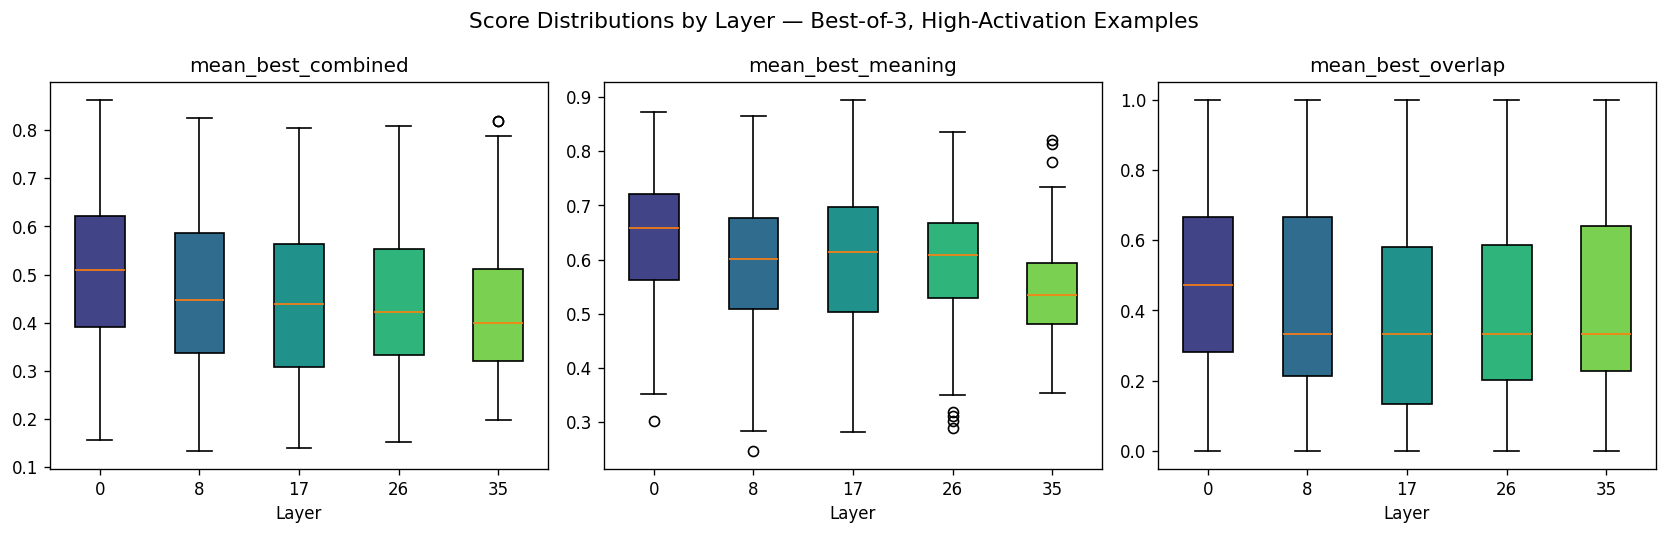

In [12]:
# Layer-wise comparison
layer_stats = neuron_best.groupby('layer')[['mean_best_combined', 'mean_best_meaning', 'mean_best_overlap']].agg(
    ['mean', 'median', 'std', 'count']
)
layer_stats.columns = ['_'.join(c) for c in layer_stats.columns]
display(layer_stats.round(3))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
layers = sorted(neuron_best['layer'].unique())

for ax, metric in zip(axes, ['mean_best_combined', 'mean_best_meaning', 'mean_best_overlap']):
    data_by_layer = [neuron_best[neuron_best['layer'] == l][metric].values for l in layers]
    bp = ax.boxplot(data_by_layer, labels=layers, patch_artist=True)
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(layers)))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    ax.set_title(metric)
    ax.set_xlabel('Layer')

fig.suptitle('Score Distributions by Layer — Best-of-3, High-Activation Examples', fontsize=13)
plt.tight_layout()
plt.show()

Overall hit rate (any overlap > 0): 47.8%
Neurons where all 3 examples hit : 117
Neurons where no example hits    : 148


/var/folders/r5/jn7w490d3tb6vq90t7pnkfqh0000gn/T/ipykernel_21958/592922823.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_by_layer, labels=layers, patch_artist=True)


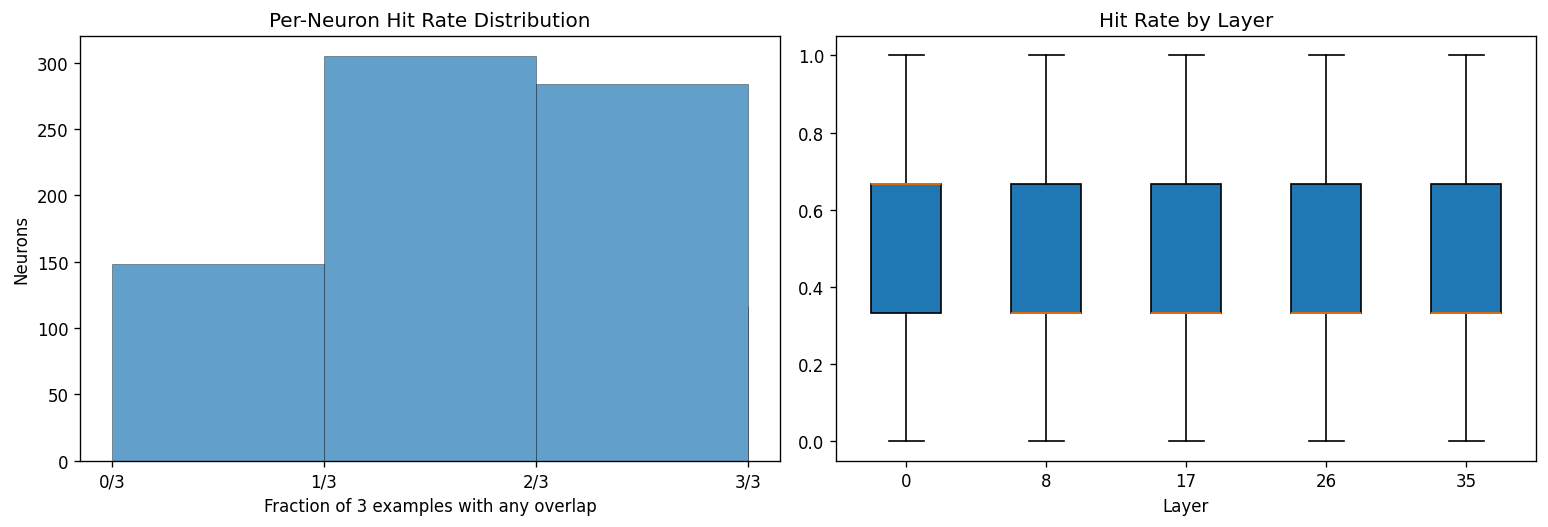

In [13]:
# Hit rate: fraction of high-activation examples where at least one of 3 predictions overlapped
overall_hit_rate = (example_scores['best_overlap'] > 0).mean()
print(f"Overall hit rate (any overlap > 0): {overall_hit_rate:.1%}")

neuron_hit_rate = (
    example_scores
    .groupby(['neuron_id', 'layer'])
    .apply(lambda g: (g['best_overlap'] > 0).mean(), include_groups=False)
    .reset_index(name='hit_rate')
)

print(f"Neurons where all 3 examples hit : {(neuron_hit_rate['hit_rate'] == 1.0).sum()}")
print(f"Neurons where no example hits    : {(neuron_hit_rate['hit_rate'] == 0.0).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(neuron_hit_rate['hit_rate'], bins=[0, 1/3, 2/3, 1, 1+1e-9],
             alpha=0.7, edgecolor='black', linewidth=0.3)
axes[0].set_xticks([0, 1/3, 2/3, 1])
axes[0].set_xticklabels(['0/3', '1/3', '2/3', '3/3'])
axes[0].set_xlabel('Fraction of 3 examples with any overlap')
axes[0].set_ylabel('Neurons')
axes[0].set_title('Per-Neuron Hit Rate Distribution')

layers = sorted(neuron_hit_rate['layer'].unique())
data_by_layer = [neuron_hit_rate[neuron_hit_rate['layer'] == l]['hit_rate'].values for l in layers]
axes[1].boxplot(data_by_layer, labels=layers, patch_artist=True)
axes[1].set_title('Hit Rate by Layer')
axes[1].set_xlabel('Layer')

plt.tight_layout()
plt.show()

In [14]:
# Sanity check: best-of-3 scores for high vs low activation examples.
# We expect high to score better on overlap/location.
example_scores_low = (
    df_low
    .groupby(['neuron_id', 'layer', 'example_idx'])
    .agg(
        best_combined = ('combined_score',   'max'),
        best_meaning  = ('meaning_score',    'max'),
        best_overlap  = ('overlap_fraction', 'max'),
        best_location = ('location_score',   'max'),
    )
    .reset_index()
)

comparison = pd.DataFrame({
    'high': example_scores[['best_combined', 'best_meaning', 'best_overlap', 'best_location']].mean(),
    'low':  example_scores_low[['best_combined', 'best_meaning', 'best_overlap', 'best_location']].mean(),
}).T

print("Mean best-of-3 scores — high vs low activation examples:")
display(comparison.round(4))

Mean best-of-3 scores — high vs low activation examples:


,best_combined,best_meaning,best_overlap,best_location
high,0.4638,0.6041,0.4082,0.1735
low,0.4962,0.5892,0.5153,0.2190


---
## 2. Outliers

In [15]:
# Load explanation previews
explanations = {}
for path in sorted(glob.glob(os.path.join(EXPL_DIR, '*_unified_scores.json'))):
    with open(path) as f:
        data = json.load(f)
    explanations[data['neuron_id']] = data.get('explanation_used', '')[:300]

neuron_best['explanation_preview'] = neuron_best['neuron_id'].map(explanations)

def print_neurons(title, subset):
    print(f"\n{'='*60}\n{title}\n{'='*60}")
    for _, row in subset.iterrows():
        print(f"\n{row['neuron_id']} (layer {row['layer']}) | mean_best_combined={row['mean_best_combined']:.3f}")
        print(f"  {row['explanation_preview']}...")

print_neurons("TOP 10 BEST (by mean_best_combined)",
              neuron_best.nlargest(10, 'mean_best_combined')[['neuron_id', 'layer', 'mean_best_combined', 'explanation_preview']])

print_neurons("TOP 10 WORST (by mean_best_combined)",
              neuron_best.nsmallest(10, 'mean_best_combined')[['neuron_id', 'layer', 'mean_best_combined', 'explanation_preview']])


TOP 10 BEST (by mean_best_combined)

0_6184 (layer 0) | mean_best_combined=0.863
  1. **Opening statement**: This neuron strongly responds to **mentions of the English language or British nationality/identity** (such as explicit references to "English" as a language, labels like "British," or contexts involving English translation, education, or colonial history).

2. **Domain cov...

0_14781 (layer 0) | mean_best_combined=0.832
  1. **Opening statement**: This neuron strongly responds to textual descriptions of **acceptance, rejection, denial, abandonment, or quitting** (such as a person or organization accepting a charge, ignoring evidence, quitting a party, denying a request, or abandoning a place).

2. **Domain coverage**...

0_453 (layer 0) | mean_best_combined=0.825
  1. **Opening statement**: This neuron strongly responds to **mentions of specific geopolitical entities, conflicts, and cultural identifiers, often within international or historical news contexts** (such as refere

Neurons where max_meaning > 0.75 but zero overlap across all examples + predictions: 31


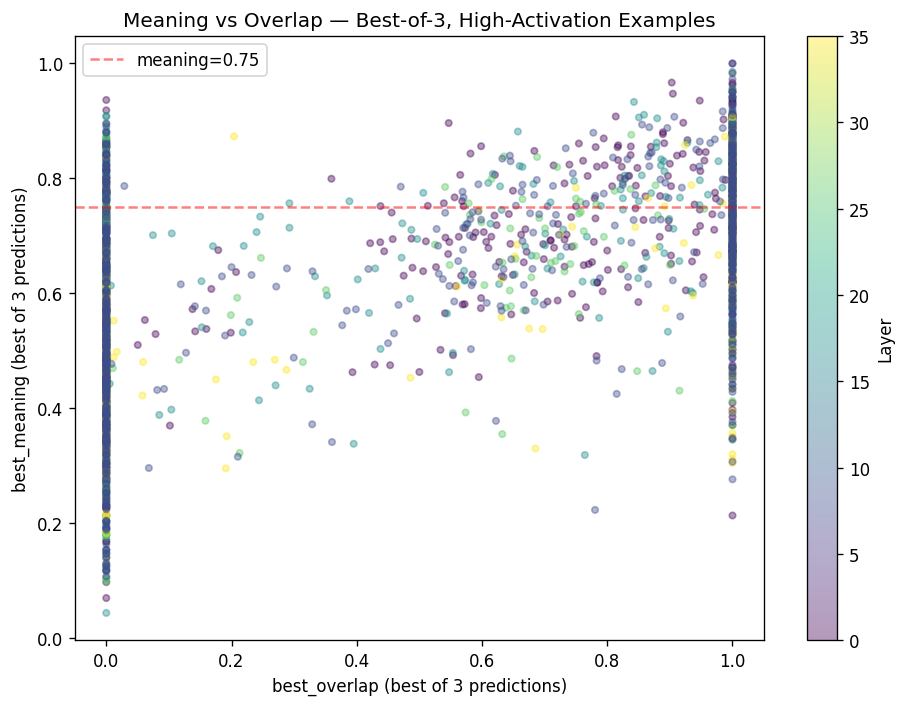

In [16]:
# Neurons where best_meaning is high but best_overlap is zero across ALL examples
# = model conceptually understands the neuron but none of its predictions ever landed
neuron_signals = example_scores.groupby('neuron_id').agg(
    max_meaning   = ('best_meaning',  'max'),
    max_overlap   = ('best_overlap',  'max'),
    mean_combined = ('best_combined', 'mean'),
).reset_index()

confidently_wrong = neuron_signals[
    (neuron_signals['max_meaning'] > 0.75) & (neuron_signals['max_overlap'] == 0.0)
].sort_values('max_meaning', ascending=False)

print(f"Neurons where max_meaning > 0.75 but zero overlap across all examples + predictions: {len(confidently_wrong)}")

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(example_scores['best_overlap'], example_scores['best_meaning'],
                c=example_scores['layer'], cmap='viridis', alpha=0.4, s=15)
ax.axhline(0.75, color='red', linestyle='--', alpha=0.5, label='meaning=0.75')
ax.set_xlabel('best_overlap (best of 3 predictions)')
ax.set_ylabel('best_meaning (best of 3 predictions)')
ax.set_title('Meaning vs Overlap — Best-of-3, High-Activation Examples')
fig.colorbar(sc, ax=ax, label='Layer')
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# Neurons with score files but no valid pairs (simulation failed)
all_score_files = sorted(glob.glob(os.path.join(EXPL_DIR, '*_unified_scores.json')))
scored_neurons = set(df['neuron_id'].unique())
all_neurons_in_files = set()

for path in all_score_files:
    with open(path) as f:
        data = json.load(f)
    all_neurons_in_files.add(data['neuron_id'])

missing = all_neurons_in_files - scored_neurons
print(f"Total unified score files : {len(all_score_files)}")
print(f"Neurons with valid pairs  : {len(scored_neurons)}")
print(f"Neurons with no pairs     : {len(missing)}")

missing_by_layer = {}
for nid in missing:
    layer = int(nid.split('_')[0])
    missing_by_layer[layer] = missing_by_layer.get(layer, 0) + 1
print("\nMissing by layer:", dict(sorted(missing_by_layer.items())))

Total unified score files : 1132
Neurons with valid pairs  : 854
Neurons with no pairs     : 278

Missing by layer: {0: 65, 8: 81, 17: 73, 26: 26, 35: 33}


---
## 3. Questions

Things I noticed in the data that I want to understand better.

### Q1: Are scores consistent across the 3 holdout examples, or does a neuron just get lucky on one?

`mean_best_combined` averages over 3 examples. A neuron could score 0.5 by nailing one example perfectly and whiffing the other two, or by scoring 0.5 on all three. These tell very different stories about explanation quality. High variance = got lucky; low variance = genuinely consistent.

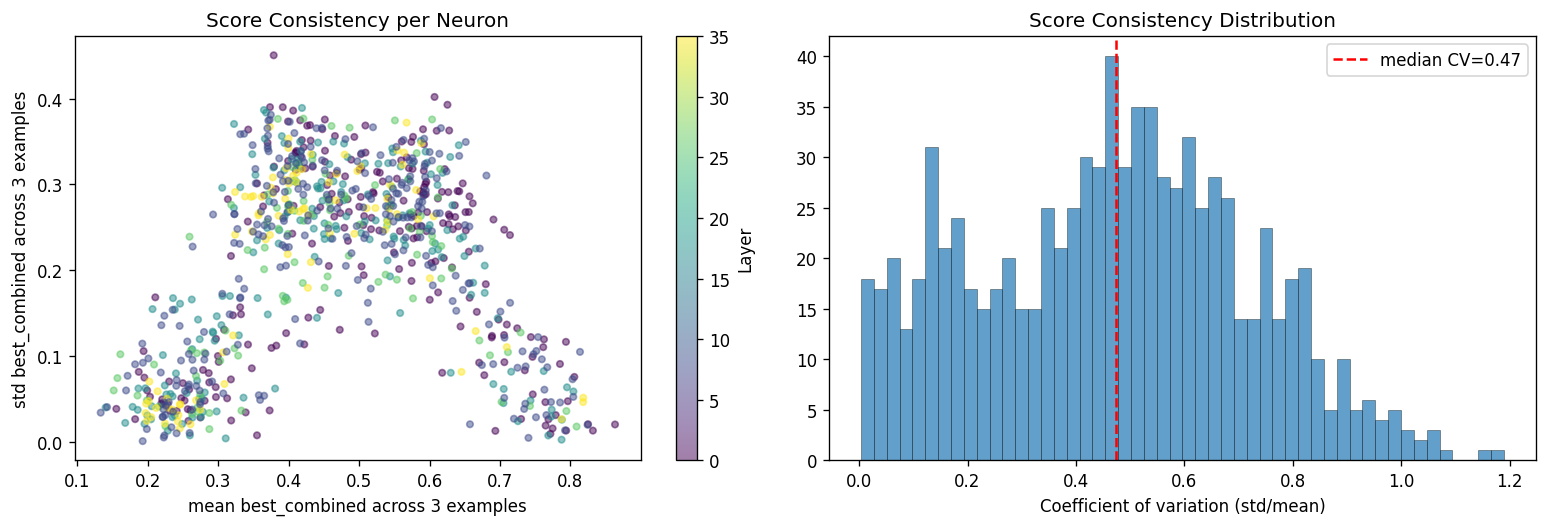

Correlation between mean score and std: 0.183
(Negative = high-scoring neurons are also more consistent)


In [18]:
neuron_consistency = (
    example_scores
    .groupby(['neuron_id', 'layer'])['best_combined']
    .agg(['mean', 'std'])
    .reset_index()
)
neuron_consistency['cv'] = neuron_consistency['std'] / neuron_consistency['mean'].clip(lower=1e-6)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sc = axes[0].scatter(neuron_consistency['mean'], neuron_consistency['std'],
                     c=neuron_consistency['layer'], cmap='viridis', alpha=0.5, s=15)
axes[0].set_xlabel('mean best_combined across 3 examples')
axes[0].set_ylabel('std best_combined across 3 examples')
axes[0].set_title('Score Consistency per Neuron')
fig.colorbar(sc, ax=axes[0], label='Layer')

axes[1].hist(neuron_consistency['cv'].clip(upper=2), bins=50, alpha=0.7, edgecolor='black', linewidth=0.3)
axes[1].axvline(neuron_consistency['cv'].median(), color='red', linestyle='--',
                label=f'median CV={neuron_consistency["cv"].median():.2f}')
axes[1].set_xlabel('Coefficient of variation (std/mean)')
axes[1].set_title('Score Consistency Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

corr = neuron_consistency['mean'].corr(neuron_consistency['std'])
print(f"Correlation between mean score and std: {corr:.3f}")
print("(Negative = high-scoring neurons are also more consistent)")

### Q2: Is `concept_score` doing anything useful?

`concept_score` is uniformly low and barely varies. Is it correlated with any other signal, or is it effectively noise? If it's decorrelated from `best_overlap` and `best_meaning`, it might be measuring something genuinely independent — or it might just be poorly calibrated.

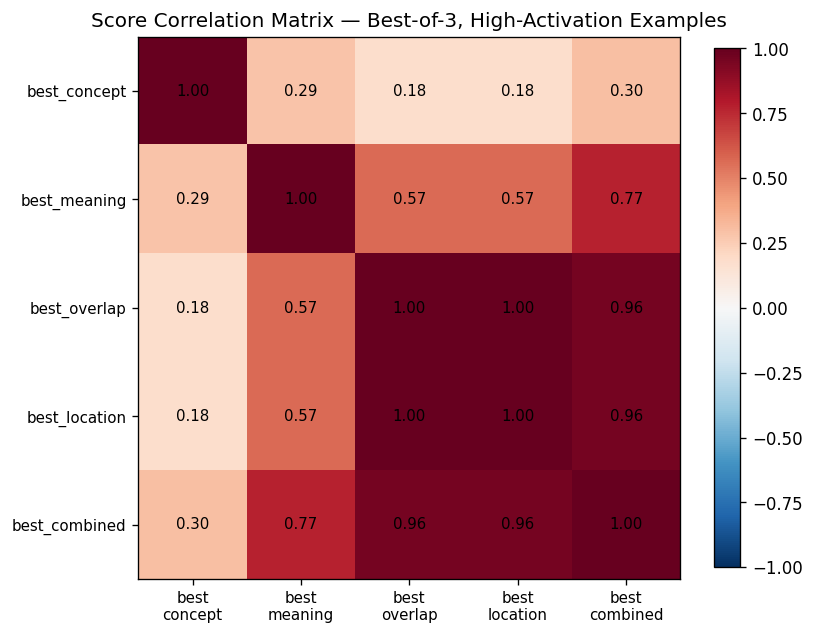

Score variances:
best_concept     0.01720
best_meaning     0.03269
best_overlap     0.20831
best_location    0.03763
best_combined    0.06310
dtype: float64


In [19]:
score_cols = ['best_concept', 'best_meaning', 'best_overlap', 'best_location', 'best_combined']
corr = example_scores[score_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(score_cols)))
ax.set_yticks(range(len(score_cols)))
ax.set_xticklabels([c.replace('_', '\n') for c in score_cols], fontsize=9)
ax.set_yticklabels(score_cols, fontsize=9)
for i in range(len(score_cols)):
    for j in range(len(score_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Score Correlation Matrix — Best-of-3, High-Activation Examples')
plt.tight_layout()
plt.show()

print("Score variances:")
print(example_scores[score_cols].var().round(5))

### Q3: Why does layer 35 consistently underperform?

Layer 35 has the lowest mean score and highest variance. Is this because deep neurons encode more abstract/distributed features, or is something about the activation magnitude distributions making the holdout harder?

High-activation example stats by layer:


,mean,std,median,count
layer,,,,
0,8.566,1.397,8.955,699
8,7.766,1.622,8.090,771
17,8.525,0.989,8.680,534
26,8.450,1.145,8.642,291
35,8.546,1.265,8.864,267


/var/folders/r5/jn7w490d3tb6vq90t7pnkfqh0000gn/T/ipykernel_21958/2360998094.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data_by_layer, labels=layers, patch_artist=True)
/var/folders/r5/jn7w490d3tb6vq90t7pnkfqh0000gn/T/ipykernel_21958/2360998094.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_by_layer2, labels=layers, patch_artist=True)


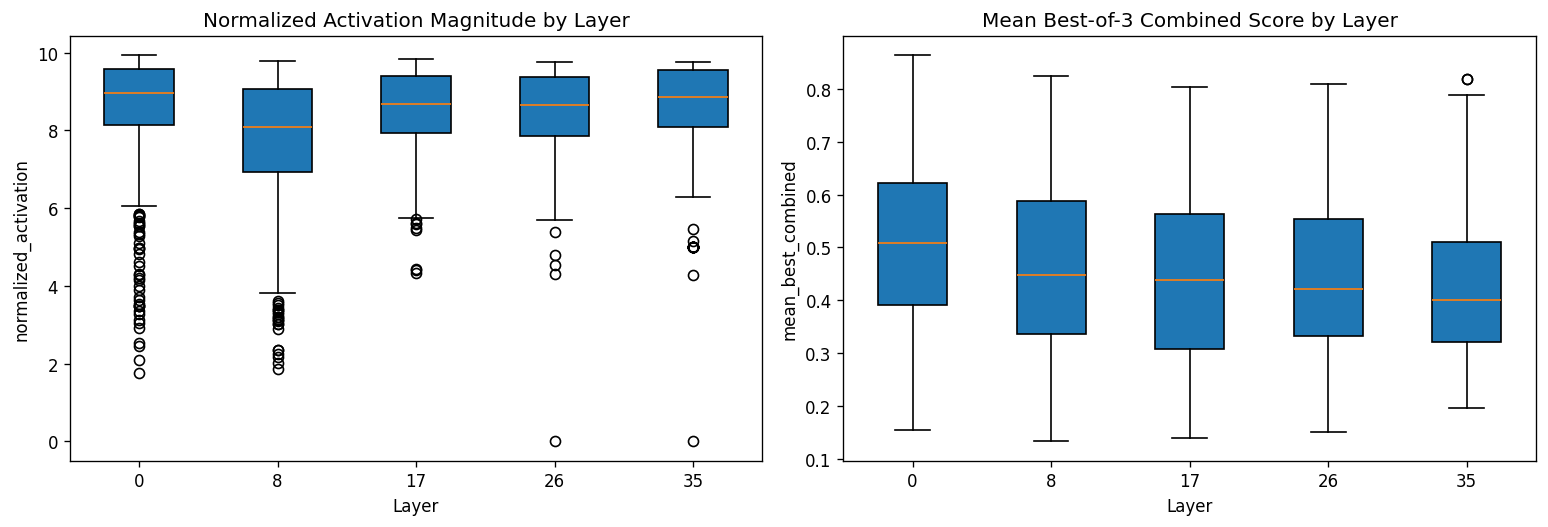

In [20]:
activation_by_layer = example_scores.groupby('layer')['normalized_activation'].agg(['mean', 'std', 'median', 'count'])
print("High-activation example stats by layer:")
display(activation_by_layer.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
layers = sorted(example_scores['layer'].unique())

data_by_layer = [example_scores[example_scores['layer'] == l]['normalized_activation'].values for l in layers]
axes[0].boxplot(data_by_layer, labels=layers, patch_artist=True)
axes[0].set_title('Normalized Activation Magnitude by Layer')
axes[0].set_xlabel('Layer')
axes[0].set_ylabel('normalized_activation')

data_by_layer2 = [neuron_best[neuron_best['layer'] == l]['mean_best_combined'].values for l in layers]
axes[1].boxplot(data_by_layer2, labels=layers, patch_artist=True)
axes[1].set_title('Mean Best-of-3 Combined Score by Layer')
axes[1].set_xlabel('Layer')
axes[1].set_ylabel('mean_best_combined')

plt.tight_layout()
plt.show()

### Q4: Are there neurons where the explanation is confidently wrong?

High `best_meaning` (model is confident it understands the concept) + zero `best_overlap` across ALL examples and ALL predictions. These are the cases where the explanation sounds right but the simulation consistently fails to land anywhere in the text.

In [21]:
confidently_wrong['explanation_preview'] = confidently_wrong['neuron_id'].map(explanations)
print(f"Confidently wrong neurons (max_meaning > 0.75, max_overlap = 0): {len(confidently_wrong)}\n")

for _, row in confidently_wrong.head(5).iterrows():
    print(f"{row['neuron_id']} | max_meaning={row['max_meaning']:.3f} mean_combined={row['mean_combined']:.3f}")
    print(f"  {row['explanation_preview']}...")
    print()

Confidently wrong neurons (max_meaning > 0.75, max_overlap = 0): 31

17_18312 | max_meaning=0.908 mean_combined=0.236
  1. **Opening statement**: This neuron strongly responds to text segments that present **claims, allegations, or contextual explanations of events** (such as allegations of framing, disputed origins of a crisis, descriptions of historical causes, or explanations of how something formed or occurred).
...

17_5565 | max_meaning=0.883 mean_combined=0.274
  1. **Opening statement**: This neuron strongly responds to **text segments discussing political or institutional power figures facing legal consequences, public scrutiny, or historical commemoration** (such as a president avoiding penalties after a conviction, a pharaoh's reign being described, or a...

8_10530 | max_meaning=0.880 mean_combined=0.282
  1. **Opening statement**: This neuron strongly responds to **text segments containing proper nouns followed by descriptive or explanatory appositives** (such as "Liz Trus

### Q5: Do neurons that activate on specific/concrete concepts score higher than abstract ones?

Intuitively, a neuron for "the word 'right'" should be easier to simulate than one for "abstract forces." The `concept` field in each prediction is a single word or phrase — shorter labels tend to be more concrete. Does concept label length correlate with score?

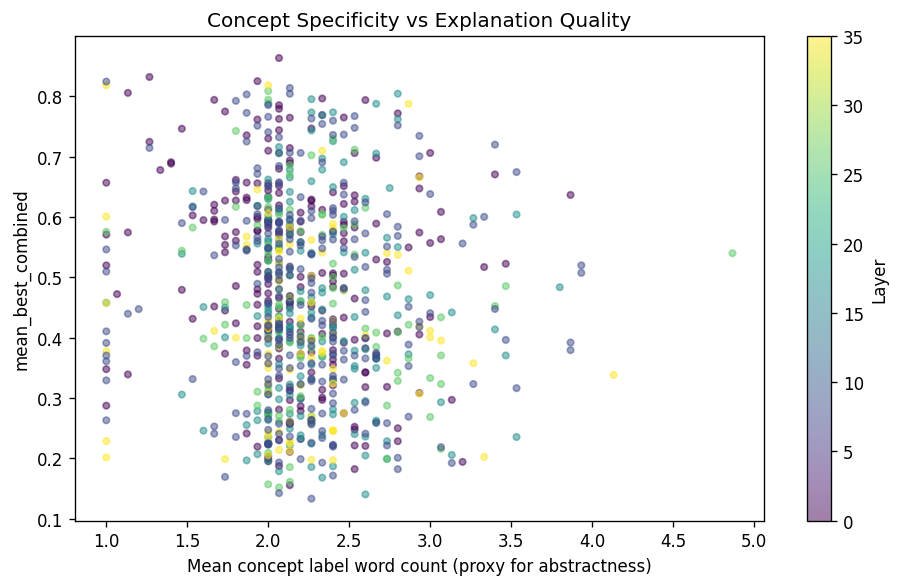

Correlation (concept word count vs mean_best_combined): -0.084


In [22]:
concept_rows = []
for path in sorted(glob.glob(os.path.join(EXPL_DIR, '*_simulation.json'))):
    with open(path) as f:
        data = json.load(f)
    nid = data.get('neuron_id', '')
    for res in data.get('results', []):
        for pred in res.get('predictions', []):
            concept = pred.get('concept', '')
            if concept:
                concept_rows.append({
                    'neuron_id': nid,
                    'concept': concept,
                    'concept_word_count': len(concept.split()),
                })

concept_df = pd.DataFrame(concept_rows)
neuron_concept_len = concept_df.groupby('neuron_id')['concept_word_count'].mean().reset_index()
neuron_concept_len.columns = ['neuron_id', 'mean_concept_words']

merged = neuron_best[['neuron_id', 'mean_best_combined', 'layer']].merge(neuron_concept_len, on='neuron_id', how='inner')

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(merged['mean_concept_words'], merged['mean_best_combined'],
                c=merged['layer'], cmap='viridis', alpha=0.5, s=15)
ax.set_xlabel('Mean concept label word count (proxy for abstractness)')
ax.set_ylabel('mean_best_combined')
ax.set_title('Concept Specificity vs Explanation Quality')
fig.colorbar(sc, ax=ax, label='Layer')
plt.tight_layout()
plt.show()

corr = merged['mean_concept_words'].corr(merged['mean_best_combined'])
print(f"Correlation (concept word count vs mean_best_combined): {corr:.3f}")